## Conclusions

- The raw gold price series (1970–2026) is non-stationary.
  Both ADF (p=0.9991) and KPSS (p=0.0100) confirmed this.

- Log returns transformation makes the series stationary.
  Both ADF (p=0.0000) and KPSS (p=0.1000) confirmed this after transformation.

- The Zivot-Andrews test identified a structural break at January 1971.
  This aligns with the Nixon Shock — the end of the Bretton Woods gold standard.
  All modeling will use post-1971 data. This decision is statistically justified,
  not assumed.

- Log returns will be used as the input for forecasting models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.stattools import zivot_andrews

df = pd.read_csv("../data/monthly.csv")
df['Date'] = pd.to_datetime(df['Date'])
df_filtered = df[df['Date'] >= '1970-01-01'].copy().reset_index(drop=True)

In [2]:
# ADF Test on Raw Price
result = adfuller(df_filtered['Price'])

print('ADF Test on Raw Price')
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print(f'Critical Values: {result[4]}')

if result[1] > 0.05:
    print("\nConclusion: Non-stationary (fail to reject null hypothesis)")
else:
    print("\nConclusion: Stationary (reject null hypothesis)")

ADF Test on Raw Price
ADF Statistic: 2.6278
p-value: 0.9991
Critical Values: {'1%': np.float64(-3.4402817347322583), '5%': np.float64(-2.8659224464259823), '10%': np.float64(-2.5691038118332603)}

Conclusion: Non-stationary (fail to reject null hypothesis)


In [3]:
# KPSS Test on Raw Price
result_kpss = kpss(df_filtered['Price'], regression='c')

print('KPSS Test on Raw Price')
print(f'KPSS Statistic: {result_kpss[0]:.4f}')
print(f'p-value: {result_kpss[1]:.4f}')
print(f'Critical Values: {result_kpss[3]}')

if result_kpss[1] < 0.05:
    print("\nConclusion: Non-stationary (reject null hypothesis)")
else:
    print("\nConclusion: Stationary (fail to reject null hypothesis)")

KPSS Test on Raw Price
KPSS Statistic: 2.9280
p-value: 0.0100
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}

Conclusion: Non-stationary (reject null hypothesis)


C:\Users\evely\AppData\Local\Temp\ipykernel_25200\4188750133.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result_kpss = kpss(df_filtered['Price'], regression='c')


In [4]:
# Calculate log returns
log_returns = np.log(df_filtered['Price'] / df_filtered['Price'].shift(1)).dropna()

# ADF on log returns
adf_result = adfuller(log_returns)
print('ADF Test on Log Returns')
print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4f}')
if adf_result[1] > 0.05:
    print("Conclusion: Non-stationary")
else:
    print("Conclusion: Stationary")

print()

# KPSS on log returns
kpss_result = kpss(log_returns, regression='c')
print('KPSS Test on Log Returns')
print(f'KPSS Statistic: {kpss_result[0]:.4f}')
print(f'p-value: {kpss_result[1]:.4f}')
if kpss_result[1] < 0.05:
    print("Conclusion: Non-stationary")
else:
    print("Conclusion: Stationary")

ADF Test on Log Returns
ADF Statistic: -5.0341
p-value: 0.0000
Conclusion: Stationary

KPSS Test on Log Returns
KPSS Statistic: 0.2343
p-value: 0.1000
Conclusion: Stationary


C:\Users\evely\AppData\Local\Temp\ipykernel_25200\4057827183.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(log_returns, regression='c')


In [5]:
# Zivot-Andrews test on raw price
result_za = zivot_andrews(df_filtered['Price'], maxlag=12, autolag='AIC')

print('Zivot-Andrews Structural Break Test')
print(f'ZA Statistic: {result_za[0]:.4f}')
print(f'p-value: {result_za[1]:.4f}')
print(f'Critical Values: {result_za[2]}')
print(f'Breakpoint index: {result_za[3]}')
print(f'Breakpoint date: {df_filtered["Date"].iloc[result_za[3]]}')

Zivot-Andrews Structural Break Test
ZA Statistic: 1.6385
p-value: 0.9990
Critical Values: {'1%': np.float64(-5.27644), '5%': np.float64(-4.81067), '10%': np.float64(-4.56618)}
Breakpoint index: 12
Breakpoint date: 1971-01-01 00:00:00


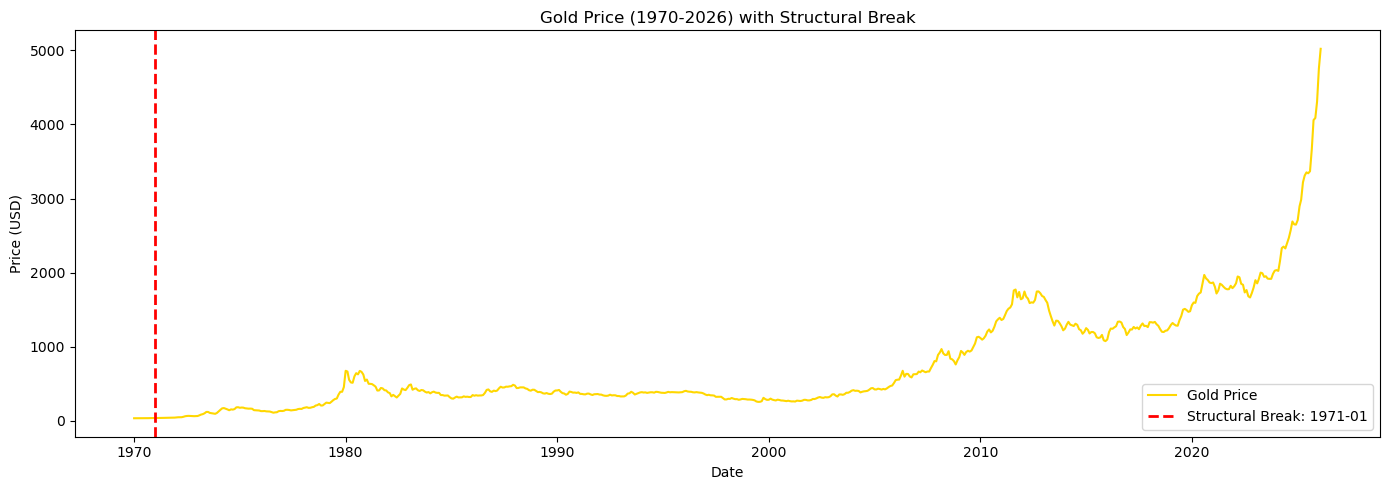

In [6]:
# Visualize the structural break
breakpoint_date = df_filtered['Date'].iloc[result_za[3]]

plt.figure(figsize=(14, 5))
plt.plot(df_filtered['Date'], df_filtered['Price'], label='Gold Price', color='gold')
plt.axvline(x=breakpoint_date, color='red', linestyle='--', linewidth=2, label=f'Structural Break: {breakpoint_date.strftime("%Y-%m")}')
plt.title('Gold Price (1970-2026) with Structural Break')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()